# U-Net Prediction Visualizations

This notebook mirrors the visualization logic from `uqct.models.unet` and renders inference examples for each dataset under both dense and sparse acquisition settings.

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


from uqct.datasets.utils import get_dataset
from uqct.metrics import get_metrics
from uqct.models.unet import FBPUNet, FBPUNetEnsemble
from uqct.training.unet import N_ANGLES, sample_intensities, MAX_TOTAL_INTENSITY, MIN_TOTAL_INTENSITY
from uqct.ct import Experiment, sample_observations, prepare_inputs_from_experiment

try:
    import lovely_tensors as lt
    lt.monkey_patch()
except Exception as _:
    pass

def build_dense_experiment(
    images: torch.Tensor, angles: torch.Tensor, n_rounds: int = 10
) -> Experiment:
    samples_cpu = images.to("cpu")
    angles_cpu = angles.to("cpu")
    batch = samples_cpu.shape[0]
    intensities = sample_intensities(
        batch,
        MIN_TOTAL_INTENSITY * n_rounds,
        MAX_TOTAL_INTENSITY,
        device=samples_cpu.device,
    ) / (n_rounds * len(angles) * images.shape[-1])
    intensities = intensities.view(-1, 1, 1, 1).expand(
        -1, n_rounds, len(angles), -1
    )
    counts = sample_observations(samples_cpu, intensities, angles_cpu)
    intensities_lr = intensities * 2
    return Experiment(counts, intensities_lr, angles_cpu, sparse=False)

def build_sparse_experiment(
    images: torch.Tensor,
    angles: torch.Tensor,
    *,
    seed: int | None = 0,
) -> Experiment:
    samples_cpu = images.to("cpu")
    angles_cpu = angles.to("cpu")
    batch = samples_cpu.shape[0]

    if seed is not None:
        prev_state = torch.random.get_rng_state()
        torch.manual_seed(seed)
    else:
        prev_state = None

    try:
        intensities = sample_intensities(
            batch,
            MIN_TOTAL_INTENSITY * len(angles),
            MAX_TOTAL_INTENSITY,
            device=samples_cpu.device,
        ) / (len(angles) * images.shape[-1])
        intensities = intensities.reshape(-1, 1, 1, 1).expand(
            -1, 1, len(angles_cpu), 1
        )
        counts = sample_observations(samples_cpu, intensities, angles_cpu)
        intensities_lr = intensities * 2
    finally:
        if prev_state is not None:
            torch.random.set_rng_state(prev_state)

    return Experiment(counts, intensities_lr, angles_cpu, sparse=True)



def build_experiment(
    samples: torch.Tensor,
    angles: torch.Tensor,
    *,
    sparse: bool,
    seed: int | None = 0,
) -> Experiment:
    if sparse:
        return build_sparse_experiment(samples, angles, seed=seed)
    return build_dense_experiment(samples, angles, n_rounds=1)


def visualize_unet_examples(
    dataset: str,
    *,
    sparse: bool,
    num_examples: int = 3,
    ensemble: bool = False
):
    """Render GT, FBP baseline, and U-Net predictions for a dataset/scenario."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.inference_mode():
        if torch.cuda.is_available():
            torch.set_float32_matmul_precision("high")
            torch.backends.cudnn.benchmark = True

        _, test_set = get_dataset(dataset, True)
        num_examples = min(num_examples, len(test_set))
        if num_examples == 0:
            raise ValueError(f"Dataset '{dataset}' has no test samples available")

        # Create experiment
        gt = torch.stack([test_set[i] for i in range(num_examples)], dim=0).to(device)
        angles = torch.from_numpy(np.linspace(0, 180, N_ANGLES, endpoint=False))
        experiment = build_experiment(gt, angles, sparse=sparse, seed=0)
        fbp_lr, intensity_vals, inferred_labels = prepare_inputs_from_experiment(experiment)

        if ensemble:
            model = FBPUNetEnsemble(dataset, sparse=sparse)
            preds = model.predict(experiment=experiment, aggregate="mean").to("cpu").squeeze(1)
        else:
            model = FBPUNet(dataset, member=0, model_device=device, sparse=sparse)
            preds = model.predict(experiment=experiment).to("cpu").squeeze(1)

        if experiment.sparse:
            preds = preds[(0, 1, 2), (9, 49, -1), 0]
            fbp_lr = fbp_lr[(0, 1, 2), (9, 49, -1), 0]
            intensity_vals = intensity_vals[(0, 1, 2), (9, 49, -1), 0]
        
        gt_lr = F.interpolate(gt, size=(128, 128), mode="area").squeeze(1).to("cpu")
        fbp = fbp_lr.to("cpu")
        if fbp.ndim == 4:
            fbp = fbp[:, -1]

        fbp_metrics, pred_metrics = [], []
        for i in range(num_examples):
            fbp_metrics.append(
                get_metrics(gt_lr[i], fbp[i].view(gt_lr[i].shape), normalize_range=True, constrained=True)
            )
            pred_metrics.append(
                get_metrics(gt_lr[i], preds[i].view(gt_lr[i].shape), normalize_range=True, constrained=True)
            )

        if sparse:
            n_angles = (10, 50, 200)
        else:
            n_angles = 3*(200,)
        fig, axes = plt.subplots(3, num_examples, figsize=(2.2 * num_examples, 6.0))
        if num_examples == 1:
            axes = np.asarray(axes).reshape(3, 1)

        image_shape = gt_lr.shape[-2:]

        for idx in range(num_examples):
            axes[0, idx].imshow(gt_lr[idx].view(image_shape), cmap="gray", vmin=0.0, vmax=1.0)
            axes[0, idx].axis("off")
            if idx == 0:
                axes[0, idx].set_title("GT", fontsize=10)
            overlay_txt = f"{int(n_angles[idx])} angles\ntotal_int={intensity_vals[idx].item():.3g}"
            axes[0, idx].text(
                6,
                4,
                overlay_txt,
                color="white",
                fontsize=8,
                ha="left",
                va="top",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.6),
            )

            axes[1, idx].imshow(fbp[idx].view(image_shape), cmap="gray", vmin=0.0, vmax=1.0)
            axes[1, idx].axis("off")
            axes[1, idx].set_title(
                f"FBP  PSNR {fbp_metrics[idx]['PSNR']:.2f}  SSIM {fbp_metrics[idx]['SS']:.3f}",
                fontsize=8,
            )

            axes[2, idx].imshow(preds[idx].view(image_shape), cmap="gray", vmin=0.0, vmax=1.0)
            axes[2, idx].axis("off")
            axes[2, idx].set_title(
                f"Pred PSNR {pred_metrics[idx]['PSNR']:.2f}  SSIM {pred_metrics[idx]['SS']:.3f}",
                fontsize=8,
            )

        title = f"{dataset.title()} | {'Sparse' if sparse else 'Dense'}"
        fig.suptitle(title, y=1.02, fontsize=12)
        fig.tight_layout()
        fig.show()

/tmp/ipykernel_68303/3183875823.py:187: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


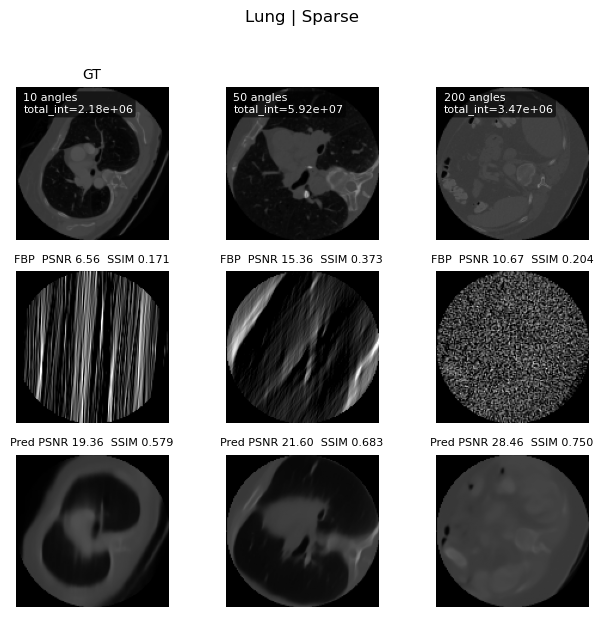

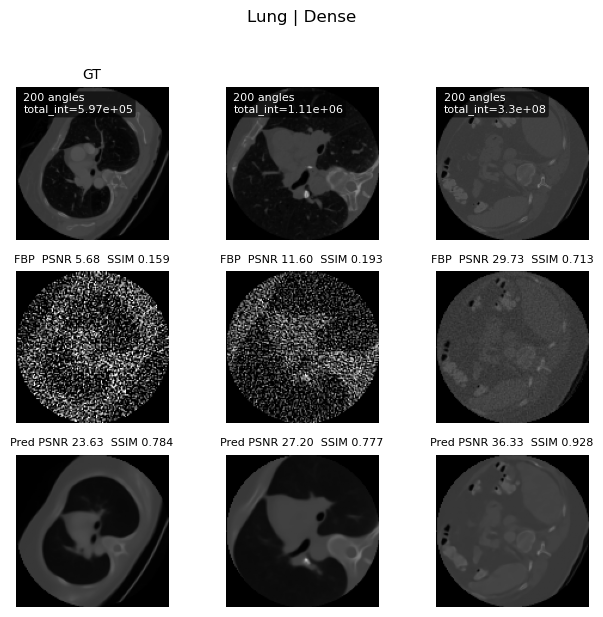

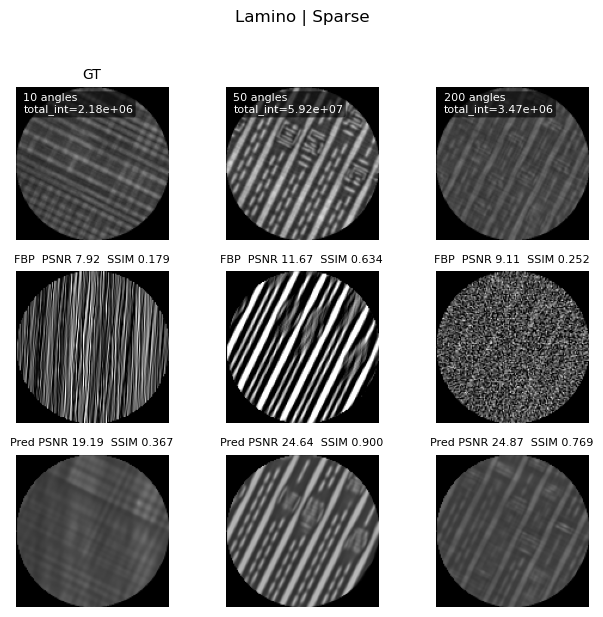

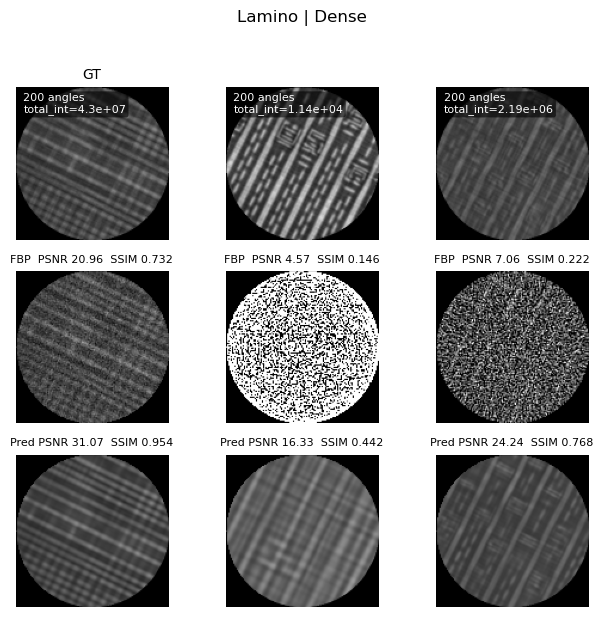

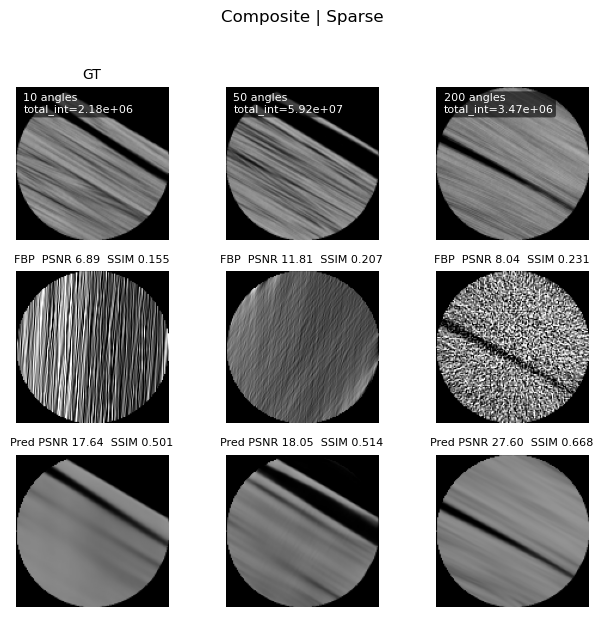

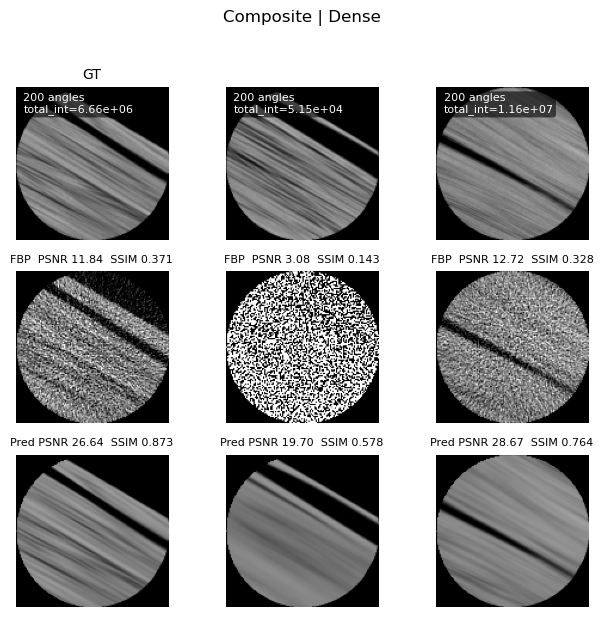

In [2]:
for dataset in ["lung", "lamino", "composite"]:
    for sparse in [True, False]:
        visualize_unet_examples(dataset, sparse=sparse)

/tmp/ipykernel_68303/3183875823.py:187: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


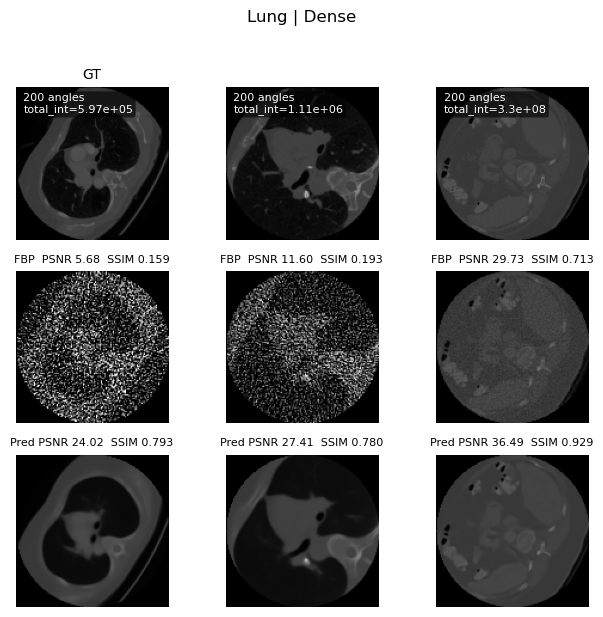

In [3]:
visualize_unet_examples("lung", sparse=False, ensemble=True)

/tmp/ipykernel_68303/3183875823.py:187: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


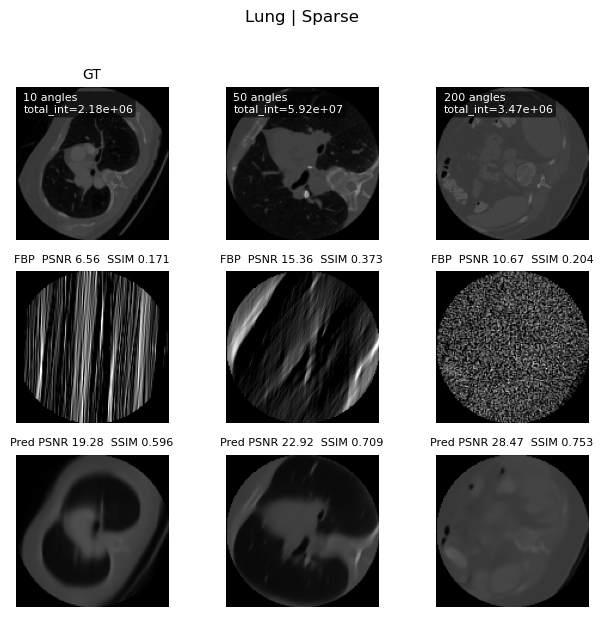

In [4]:
visualize_unet_examples("lung", sparse=True, ensemble=True)

/tmp/ipykernel_68303/3183875823.py:187: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


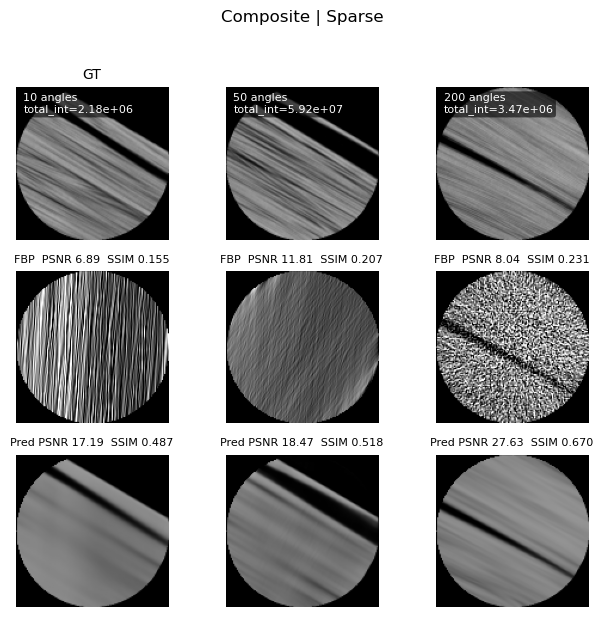

In [6]:
visualize_unet_examples("composite", sparse=True, ensemble=True)